In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from bluemath_tk.core.io import load_model

#### Load Data

In [ ]:
centroids_df = pd.read_csv(f'outputs/KMA/centroids_kma_sorted.csv', index_col=0)
nearest_centroids_df = pd.read_csv(f'outputs/KMA/nearest_centroids_df_kma_sorted.csv', index_col=0)
nearest_centroids_idx= pd.read_csv(f'outputs/KMA/nearest_centroids_idxs_kma_sorted.csv', index_col=0)

In [3]:
centroids_df 

,dp0g1,dp0g2,dp0g3,dp0g4,dp1g1,dp1g2,dp1g3,dp1g4,hs0g1,hs0g2,...,wd0g4,ws0g1,ws0g2,ws0g3,ws0g4,hs_totalg1,hs_totalg2,hs_totalg3,hs_totalg4,hs_total_avg
kma_bmus,,,,,,,,,,,,,,,,,,,,,
126,233.002170,221.321380,152.00706,134.159330,143.355090,142.964300,168.186000,158.156460,3.764003,3.629424,...,121.572744,20.117091,21.585839,22.759026,16.327751,5.696502,6.532300,9.655147,7.236809,7.280189
95,110.915700,121.615440,131.48915,125.326550,171.738500,176.147140,179.511800,149.725740,3.011760,2.737005,...,116.437468,17.181788,16.220901,10.540514,6.634176,6.468140,6.189592,5.146850,2.917222,5.180451
119,239.469540,229.678400,200.67264,168.869980,144.088680,134.448260,126.495400,125.572174,1.848053,1.964192,...,196.820829,12.015882,12.440818,13.894698,12.470560,3.993667,4.270995,5.527408,5.052266,4.711084
23,45.279793,48.207623,51.42470,49.475723,106.365135,103.271100,103.745010,101.121056,2.071686,2.289286,...,33.846004,12.541742,13.259048,14.211601,12.397095,3.854738,4.237133,5.138799,5.167538,4.599552
25,227.889700,79.176600,76.99772,66.336464,106.110920,99.773710,101.201170,105.408750,1.516057,1.617552,...,56.261138,11.229962,11.792700,14.492733,13.210695,3.214924,3.835685,5.493859,5.359910,4.476095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,129.754930,131.286100,141.47688,137.584690,125.913490,126.622600,132.823520,133.049120,0.245613,0.254162,...,140.521470,3.989072,4.070567,4.346205,3.952215,0.962753,0.970673,1.012843,0.971910,0.979545
2,84.718864,78.244900,68.97585,147.000780,107.101746,105.422554,101.077860,100.592430,0.241072,0.201159,...,214.105300,3.994731,3.845873,3.512844,3.096157,0.992422,0.967658,0.963963,0.926580,0.962656
71,79.777940,74.332664,229.75775,103.616250,125.870670,123.724380,117.950740,124.246210,0.157817,0.151672,...,192.235450,3.740037,3.697417,4.536764,4.667119,0.859853,0.856811,1.026395,1.048115,0.947793


In [4]:
# centroids_df= centroids_df.drop(columns=['hsg_avg'])
# centroids_df= centroids_df.drop(columns=['hs_sum_g1'])
centroids_df= centroids_df.drop(columns=['hs_totalg1',	'hs_totalg2',	'hs_totalg3',	'hs_totalg4',	'hs_total_avg'])

centroids_df.head()

,dp0g1,dp0g2,dp0g3,dp0g4,dp1g1,dp1g2,dp1g3,dp1g4,hs0g1,hs0g2,...,tp1g3,tp1g4,wd0g1,wd0g2,wd0g3,wd0g4,ws0g1,ws0g2,ws0g3,ws0g4
kma_bmus,,,,,,,,,,,,,,,,,,,,,
126,233.002170,221.321380,152.00706,134.159330,143.355090,142.96430,168.18600,158.156460,3.764003,3.629424,...,12.545710,11.602006,286.967683,273.318162,136.667012,121.572744,20.117091,21.585839,22.759026,16.327751
95,110.915700,121.615440,131.48915,125.326550,171.738500,176.14714,179.51180,149.725740,3.011760,2.737005,...,13.647295,11.406211,88.660108,99.873020,113.711939,116.437468,17.181788,16.220901,10.540514,6.634176
119,239.469540,229.678400,200.67264,168.869980,144.088680,134.44826,126.49540,125.572174,1.848053,1.964192,...,9.266826,9.191651,258.211884,248.080310,220.037305,196.820829,12.015882,12.440818,13.894698,12.470560
23,45.279793,48.207623,51.42470,49.475723,106.365135,103.27110,103.74501,101.121056,2.071686,2.289286,...,9.426130,9.334442,22.537725,28.418356,27.819568,33.846004,12.541742,13.259048,14.211601,12.397095
25,227.889700,79.176600,76.99772,66.336464,106.110920,99.77371,101.20117,105.408750,1.516057,1.617552,...,8.883035,8.857621,330.045123,285.257569,52.326244,56.261138,11.229962,11.792700,14.492733,13.210695


In [5]:
nearest_centroids_idx

,kma_bmus,kma_bmus_orig,kma_bmus_sorted
1980-01-01,140,140,82
1980-01-02,106,106,67
1980-01-03,50,50,57
1980-01-04,28,28,106
1980-01-05,11,11,64
...,...,...,...
2023-12-27,33,33,26
2023-12-28,38,38,22
2023-12-29,102,102,125
2023-12-30,78,78,56


In [6]:
nearest_centroids_df 

,dp0g1,dp0g2,dp0g3,dp0g4,dp1g1,dp1g2,dp1g3,dp1g4,hs0g1,hs0g2,...,wd0g1,wd0g2,wd0g3,wd0g4,ws0g1,ws0g2,ws0g3,ws0g4,kma_bmus,kma_bmus_sorted
1980-01-01,11.369049,23.596039,36.762910,42.303160,83.274260,87.456085,146.435000,30.113525,0.504218,1.092657,...,343.059347,357.431806,28.793336,46.879320,6.794482,8.926181,10.832924,8.401535,140,82
1980-01-02,311.676700,324.960140,6.120483,8.173706,171.626460,85.963380,70.231690,74.062805,1.109726,1.118281,...,313.736234,318.592456,336.293129,346.699814,9.916078,10.299135,12.306847,11.604951,106,67
1980-01-03,353.975900,343.836150,345.953600,333.084840,70.085420,62.904877,50.527283,54.089110,0.309096,0.289012,...,0.701913,349.223979,339.195547,327.400677,4.958947,5.421560,6.140924,7.739953,50,57
1980-01-04,66.610535,84.603670,70.481750,46.614290,70.112460,64.404175,50.212250,44.358154,0.182427,0.306896,...,98.817560,99.419199,68.972997,47.526108,4.228852,4.961302,6.692020,7.123397,28,106
1980-01-05,318.671420,313.440200,358.071900,33.345734,173.840640,156.619570,54.617310,92.664430,1.289812,1.219720,...,318.105656,318.722730,320.125084,16.728776,10.617166,10.577474,10.336028,12.739545,11,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,159.589970,154.263800,142.150200,113.220700,108.438510,113.500430,140.402800,108.095184,1.537852,1.728324,...,167.668978,160.391985,132.359039,109.294437,8.028384,8.752776,9.849789,6.400503,33,26
2023-12-28,247.635680,237.278530,229.743480,206.890990,115.379730,110.423800,128.037930,137.766360,0.999801,0.995721,...,267.395319,264.031367,254.540372,252.202011,9.162432,9.425423,8.499945,5.604288,38,22
2023-12-29,233.459410,234.366060,230.651410,216.311510,112.857025,106.291080,139.267300,130.203220,1.249844,1.204726,...,253.636841,254.091113,247.685698,230.156499,9.627664,8.985215,7.107272,6.160563,102,125
2023-12-30,249.984600,247.507980,237.124700,255.306700,192.969510,192.414140,182.973790,164.595460,1.946958,1.852688,...,276.031332,275.412867,267.893310,261.024545,12.575667,12.250268,11.648194,9.915409,78,56


In [7]:
pcs_df = pd.read_csv('outputs/PCA/pcs_mslp_df.csv', index_col=0, parse_dates=True)
# pcs_df = pd.read_csv('outputs/PCA_95/pcs_mslp_df.csv', index_col=0, parse_dates=True)
# Add kma_bmus by matching dates with nearest_centroids_idx; keep only common dates
nc = nearest_centroids_idx.copy()
nc.index = pd.to_datetime(nc.index, format='mixed').normalize()
common_dates = pcs_df.index.normalize().intersection(nc.index)
pcs_df = pcs_df.loc[pcs_df.index.normalize().isin(common_dates)]
pcs_df['kma_bmus'] = nc.reindex(pcs_df.index.normalize())['kma_bmus_sorted'].values
pcs_df.to_csv('outputs/PCA/pcs_clusters_ordered_ERA5.csv')
pcs_df.head(20)

/tmp/ipykernel_3710820/2798508912.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcs_df['kma_bmus'] = nc.reindex(pcs_df.index.normalize())['kma_bmus_sorted'].values


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC414,PC415,PC416,PC417,PC418,PC419,PC420,PC421,PC422,kma_bmus
1980-01-01,-49.458400,-34.048107,-7.929733,-0.975224,-23.111797,5.615498,-13.778695,3.980211,0.646035,-25.690119,...,-1.207088,-0.051512,-0.116706,-0.139034,0.895172,1.738079,0.481316,1.242083,0.381649,82
1980-01-02,-55.407116,-25.120966,-15.827502,4.537589,-24.490154,7.925308,-18.712046,7.001968,2.070619,-13.881749,...,0.333494,-0.688912,0.324859,0.914038,0.563842,0.911562,-0.177970,0.123352,-0.992092,67
1980-01-03,-56.924335,-17.005570,-18.541697,11.153529,-23.551619,11.860006,-17.197592,8.691975,1.607635,-3.346325,...,1.006207,0.585742,-0.303038,0.473561,-1.106718,0.601525,0.486609,-0.385596,0.221510,57
1980-01-04,-55.253220,-11.977421,-16.137165,13.210090,-16.443144,10.612020,-6.392672,13.554341,-0.226324,5.771776,...,-0.013758,-0.041140,0.464463,0.032919,0.315654,-1.283754,-0.402260,-0.350686,0.502584,106
1980-01-05,-47.471718,-7.726556,-12.295485,10.334167,-14.233707,8.815292,5.338915,16.309042,-11.480149,2.939295,...,-1.435816,-2.086801,0.540014,-0.443706,-0.636304,0.640091,-0.084544,1.144686,-1.595476,64
1980-01-06,-41.984394,-3.156262,-8.090857,9.345588,-19.545244,10.517530,6.814421,10.253082,-9.603621,-7.065017,...,-0.602329,0.725590,-0.707149,-0.504393,-0.118753,0.065669,0.944582,-0.104356,0.914001,6
1980-01-07,-38.009720,4.019625,-5.887105,13.379266,-20.226370,4.801418,6.400393,11.723924,-8.659736,-8.612528,...,0.051424,0.821256,-2.687226,0.651472,1.059976,-1.929149,-0.453576,1.068940,0.618271,43
1980-01-08,-34.863663,11.881107,-6.606359,17.054499,-15.121107,0.562327,7.612006,16.370739,-6.755383,-10.065058,...,1.001702,-0.064835,1.070372,1.129120,-1.428332,-0.093315,1.185032,0.751979,-1.476684,75
1980-01-09,-33.971447,18.720575,-5.965404,16.722181,-10.919018,-5.900314,14.618680,20.214432,-2.905432,-10.410510,...,-0.098284,0.475928,-0.874887,-0.678157,-1.394359,-0.716754,0.984028,0.583310,0.910224,81
1980-01-10,-28.490183,22.090690,-1.804453,9.930626,-4.594120,-12.815430,17.030561,23.749277,1.279469,-9.830633,...,-0.510699,1.297119,-0.641934,-1.033464,1.170796,-0.106079,0.916167,-0.007603,-1.205183,69


In [8]:
nearest_centroids_df.index = pd.to_datetime(nearest_centroids_df.index, format='mixed')

In [9]:
pcs_df.index = pd.to_datetime(pcs_df.index, format='mixed')

In [10]:
nearest_centroids_df['energy'] = nearest_centroids_df['hs1g1']**2*nearest_centroids_df['tp1g1']
nearest_centroids_df_aux = nearest_centroids_df.loc[pcs_df.index]

from sklearn.linear_model import LinearRegression
X = pcs_df.iloc[:,:-1].values
y = nearest_centroids_df_aux['energy'].values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)


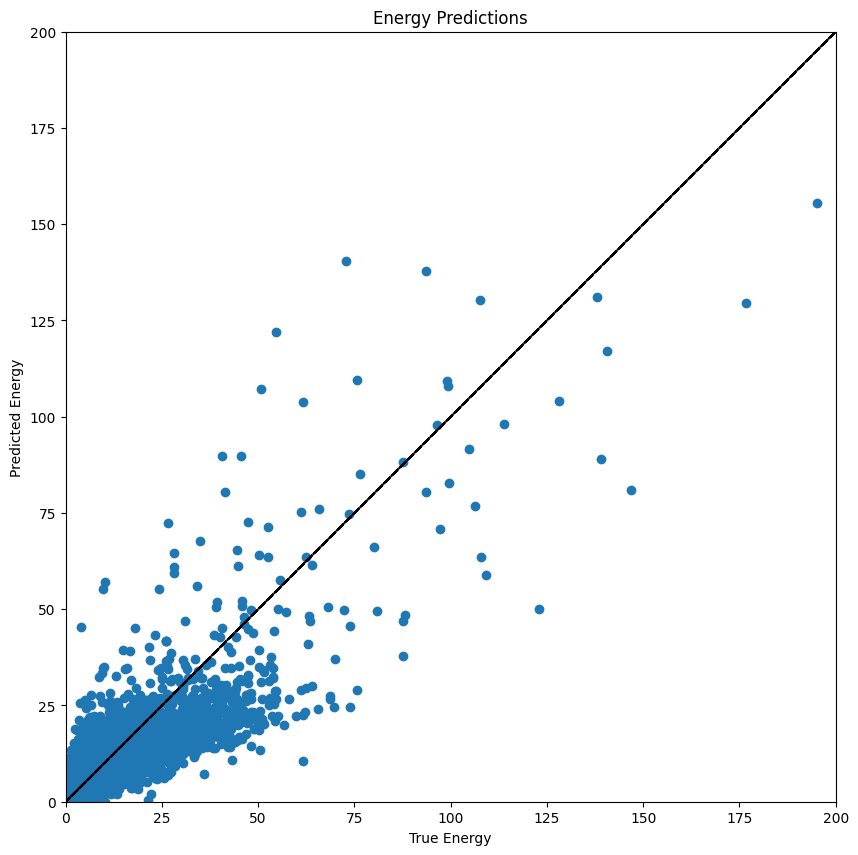

In [11]:
fig, ax = plt.subplots(1,1, figsize=(10,10))

ax.scatter(y,y_pred)
ax.plot(y,y, color='k', linestyle='--')
ax.set_aspect('equal')
ax.set_xlabel('True Energy')
ax.set_ylabel('Predicted Energy')
ax.set_title('Energy Predictions')
ax.set_ylim(0,200)
ax.set_xlim(0,200)
plt.show()


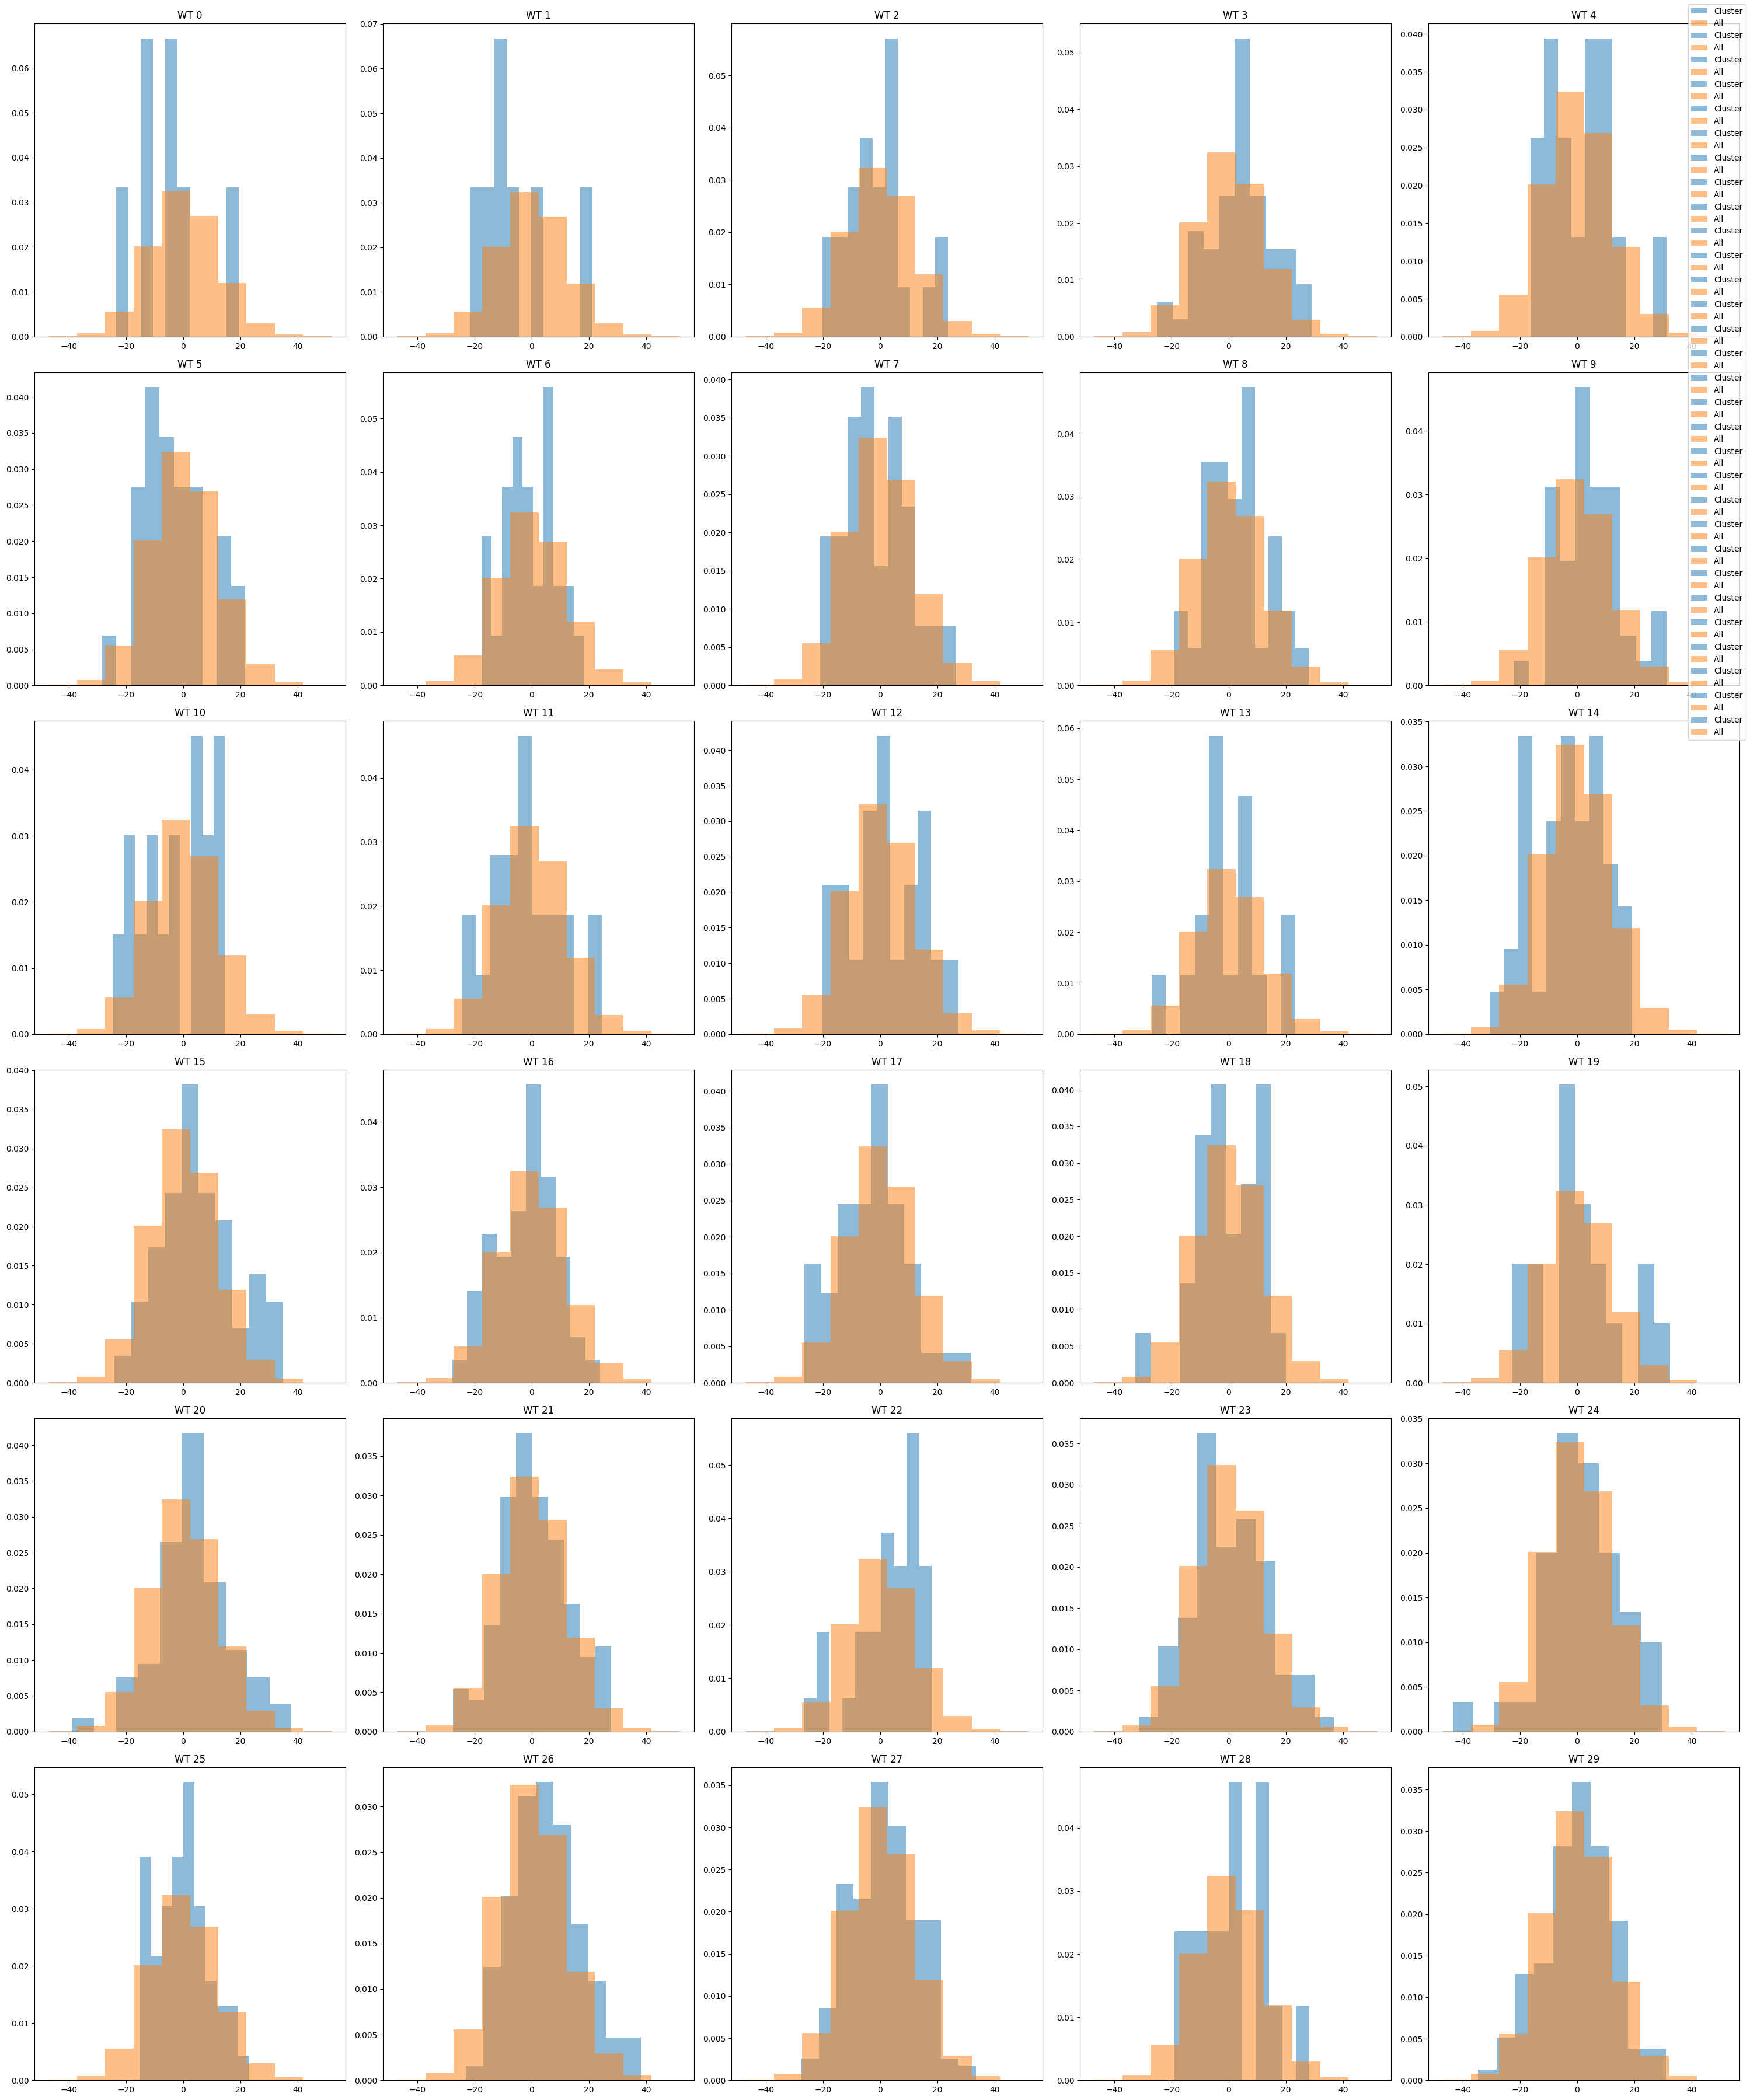

In [12]:
fig, axes = plt.subplots(6,5, figsize=(30,36))
pc = 9
axes = axes.flatten()

for i, ax in enumerate(axes):
    aux_df = pcs_df[pcs_df['kma_bmus'] == i]
    ax.hist(aux_df.iloc[:,pc], density=True, alpha=0.5, label='Cluster')
    ax.hist(pcs_df.iloc[:,pc], density=True, alpha=0.5, label='All')
    ax.set_title(f'WT {i}')

fig.legend()
plt.tight_layout()
plt.show()
